In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shahdelmasry23/telco-costumer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


# ***Imports***

In [2]:
import numpy as np # linear algebra
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV 

# ***Load dataset***

## Dataset Description

This dataset contains information about telecommunications customers and their subscription services. The main objective is to predict whether a customer will leave the company or not. The target variable is `Churn`.

| Column             | Description                                                          |
| ------------------ | -------------------------------------------------------------------- |
| `customerID`       | Unique identifier for each customer.                                 |
| `gender`           | Customer's gender.                                                   |
| `SeniorCitizen`    | Indicates whether the customer is a senior citizen.                  |
| `Partner`          | Indicates whether the customer has a partner.                        |
| `Dependents`       | Indicates whether the customer has dependents.                       |
| `tenure`           | Number of months the customer has stayed with the company.           |
| `PhoneService`     | Indicates whether the customer has phone service.                    |
| `MultipleLines`    | Indicates whether the customer has multiple phone lines.             |
| `InternetService`  | Type of internet service used by the customer.                       |
| `OnlineSecurity`   | Indicates whether the customer has online security service.          |
| `OnlineBackup`     | Indicates whether the customer has online backup service.            |
| `DeviceProtection` | Indicates whether the customer has device protection service.        |
| `TechSupport`      | Indicates whether the customer has technical support service.        |
| `StreamingTV`      | Indicates whether the customer has a TV streaming service.           |
| `StreamingMovies`  | Indicates whether the customer has a movie streaming service.        |
| `Contract`         | Type of contract the customer has with the company.                  |
| `PaperlessBilling` | Indicates whether the customer uses paperless billing.               |
| `PaymentMethod`    | Payment method used by the customer.                                 |
| `MonthlyCharges`   | Amount charged to the customer each month.                           |
| `TotalCharges`     | Total amount charged to the customer during the subscription period. |
| `Churn`            | Target variable. Indicates whether the customer left the company.    |


In [3]:
data='/kaggle/input/datasets/shahdelmasry23/telco-costumer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df=pd.read_csv(data)
df.head() # View firts five rows(instance)'
df=pd.read_csv(data)

# ***Part 1 — Data Exploration(EDA)***

In [4]:
# View firts five rows(instance)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Veiw dimensions of dataset
#(Number of samples,Number of features)//(# Rows,# Columns)
df.shape

(7043, 21)

In [6]:
#Data type
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [7]:
#using info to see summery of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
#Missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
#Duplicate values
df.duplicated().sum()

np.int64(0)

In [10]:
#Descriptive statistics For numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [11]:
# use describe function on object dtype 
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [12]:
#Number of different values in textual texts
categorical_columns = df.select_dtypes(include='object').columns
#printing the unique values
for column in categorical_columns:
    print(column,df[column].unique())
    print(f"Number of unique values: {df[column].nunique()}")
    print("*"*50)

customerID ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
Number of unique values: 7043
**************************************************
gender ['Female' 'Male']
Number of unique values: 2
**************************************************
Partner ['Yes' 'No']
Number of unique values: 2
**************************************************
Dependents ['No' 'Yes']
Number of unique values: 2
**************************************************
PhoneService ['No' 'Yes']
Number of unique values: 2
**************************************************
MultipleLines ['No phone service' 'No' 'Yes']
Number of unique values: 3
**************************************************
InternetService ['DSL' 'Fiber optic' 'No']
Number of unique values: 3
**************************************************
OnlineSecurity ['No' 'Yes' 'No internet service']
Number of unique values: 3
**************************************************
OnlineBackup ['Yes' 'No' 'No internet serv

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


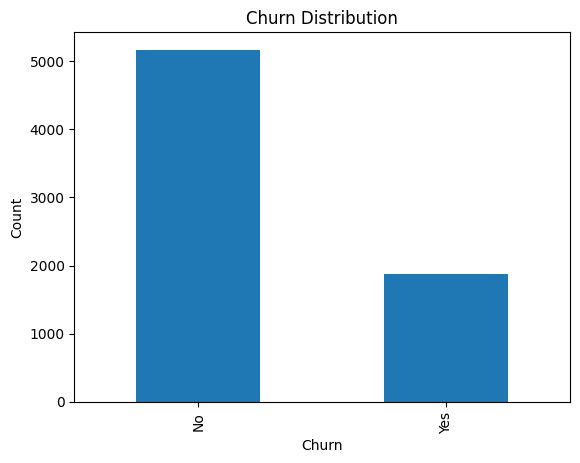

In [13]:
# Target Churn distribution.
print(df["Churn"].value_counts(normalize=True)*100)#normalize=True--->To Calculate the percentage for each value


df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

In [14]:
#Percentage of customers who left the company.
print("Percentage of customers who left the company: ",df['Churn'].value_counts(normalize=True)['Yes']* 100)

Percentage of customers who left the company:  26.536987079369588


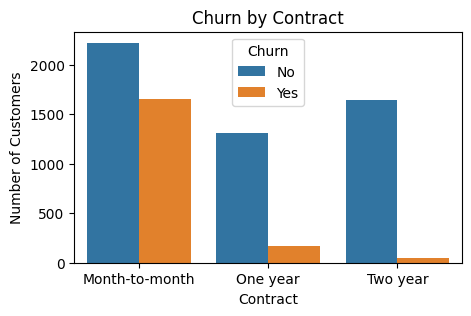

In [15]:
#Contract relationship with Churn
plt.figure(figsize=(5,3))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")
plt.show()

#### Contract relationship with Churn 
   * We conclude that the longer the contract period with the company, the greater the chance of the customer remaining with the company.

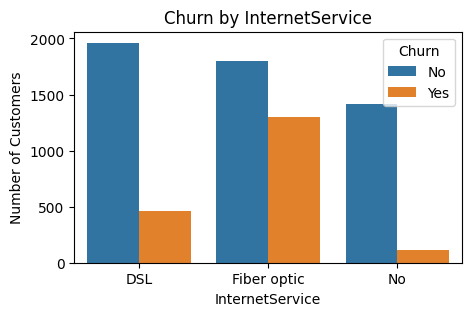

In [16]:
#InternetService's relationship with Churn
plt.figure(figsize=(5,3))
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Churn by InternetService")
plt.xlabel("InternetService")
plt.ylabel("Number of Customers")
plt.show()

#### InternetService's relationship with Churn
  * We conclude that customers with DSL internet service or no internet service are more likely to stay than those with fiber optic internet service.

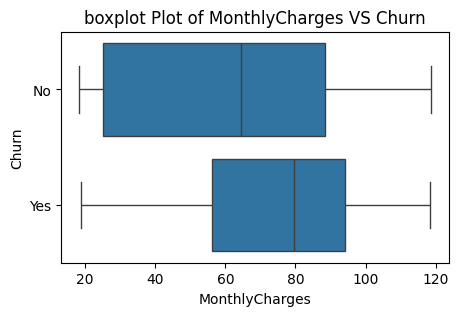

In [17]:
# MonthlyCharges compares customers who quit and those who did not. By using Box Plot Because of comparing a numerical variable between categories
plt.figure(figsize=(5, 3))
sns.boxplot(x=df["MonthlyCharges"], y=df["Churn"])
plt.title("boxplot Plot of MonthlyCharges VS Churn")
plt.xlabel("MonthlyCharges")
plt.ylabel("Churn")
plt.show()

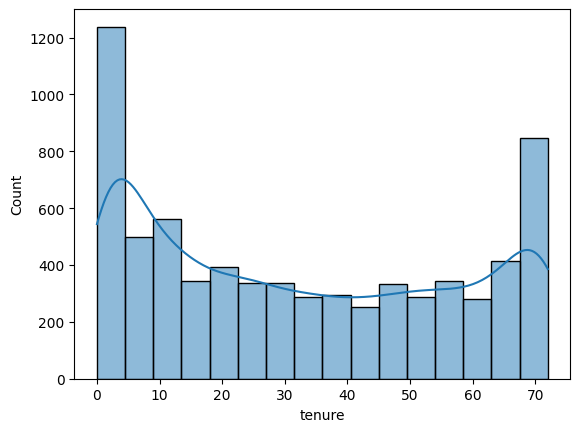

In [18]:
#Distribution of tenure.By using Histplot Becuase it use to Know the distribution of a numerical variable
sns.histplot(df["tenure"], kde=True)
plt.show()

In [19]:
#To make the letters of each column a lower letter
df.columns = df.columns.str.lower()
df.head().T

,0,1,2,3,4
customerid,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
seniorcitizen,0,0,0,0,0
partner,Yes,No,No,No,No
dependents,No,No,No,No,No
tenure,1,34,2,45,2
phoneservice,No,Yes,Yes,No,Yes
multiplelines,No phone service,No,No,No phone service,No
internetservice,DSL,DSL,DSL,DSL,Fiber optic
onlinesecurity,No,Yes,Yes,Yes,No


# ***Part 2 — Data Cleaning and Preprocessing***

In [20]:
df["totalcharges"].dtype # is object but it must be float

dtype('O')

In [21]:
#Fix Data Types
#### TotalCharges column ####

In [22]:
df.totalcharges.describe()

count     7043
unique    6531
top           
freq        11
Name: totalcharges, dtype: object

In [23]:
#To find out how many rows equal spaces in the Totalcharges column
len(df[df.totalcharges.str.contains(" ")])

11

In [24]:
#To convert the data type of the Totalcharges column from object to Float
df["totalcharges"]= pd.to_numeric(df.totalcharges,errors="coerce") #errors="coerce" -->makes any non-convertible value NaN

In [25]:
#To delete rows that contain null values from a Totalcharges column
df.dropna(subset=["totalcharges"],inplace=True)


In [26]:
df["totalcharges"].isnull().sum()

np.int64(0)

In [27]:
df["totalcharges"].describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: totalcharges, dtype: float64

In [28]:
# Identify the Target
# Separate features and target variable
x = df.drop("churn", axis=1)
y = df['churn'].map({
    'No': 0,
    'Yes': 1
})

x.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [29]:
print(y.value_counts())

churn
0    5163
1    1869
Name: count, dtype: int64


In [30]:
#Remove Irrelevant Columns
#remove columns ( customerID ) becuase its don't  provide useful information for the model or effect
x.drop("customerid",axis=1,inplace=True) #axis=1 --> applied to columns 
#inplace=True -->updates the original DataFrame directly without creating a new one.)

In [31]:

#x_train,x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)

print("Training set shape:", x_train.shape)
print("Testing set shape:", x_test.shape)
# test_size=0.2-->20% from all data to test data
# random_state=42--->To get the same split every time the code runs
# stratify=y--->This makes the Target distribution in Training and Testing close to its distribution in the original data.

Training set shape: (5625, 19)
Testing set shape: (1407, 19)


In [32]:
# Numerical columns
numerical_features = x_train.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
categorical_features = x_train.select_dtypes(include=['object']).columns
print("Numerical columns:")
print(numerical_features)

print("\nCategorical columns:")
print(categorical_features)

Numerical columns:
Index(['seniorcitizen', 'tenure', 'monthlycharges', 'totalcharges'], dtype='object')

Categorical columns:
Index(['gender', 'partner', 'dependents', 'phoneservice', 'multiplelines',
       'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection',
       'techsupport', 'streamingtv', 'streamingmovies', 'contract',
       'paperlessbilling', 'paymentmethod'],
      dtype='object')


In [33]:
#5. Numerical Preprocessing
# Apply StandardScaler to numerical columns
scaler = StandardScaler()
x_train[numerical_features]=scaler.fit_transform(x_train[numerical_features])
x_test[numerical_features]=scaler.transform(x_test[numerical_features])
x_train.head()
#StandardScaler is used to ensure that values are measured around a mean of 0 and a standard deviation of 1, and to prevent the model from being biased towards large values.
#Which models are affected by scaling?--->KNN and Logistic regrassion

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges
1413,Male,-0.439319,Yes,Yes,1.321816,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,No,No,Two year,No,Credit card (automatic),0.981556,1.659900
7003,Male,-0.439319,No,No,-0.267410,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,No,Electronic check,-0.971546,-0.562252
3355,Female,-0.439319,Yes,No,1.444064,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,No,No,Two year,No,Credit card (automatic),0.837066,1.756104
4494,Male,-0.439319,No,No,-1.204646,Yes,No,Fiber optic,No,Yes,No,No,No,Yes,Month-to-month,No,Electronic check,0.641092,-0.908326
3541,Female,-0.439319,Yes,No,0.669826,No,No phone service,DSL,Yes,No,No,No,Yes,No,Month-to-month,No,Bank transfer (automatic),-0.808787,-0.101561


In [34]:
#Use Pipeline
# Numerical preprocessing
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
# Combine preprocessing steps
preprocessor = ColumnTransformer(transformers=[
    ('numerical', numerical_pipeline, numerical_features),
    ('categorical', categorical_pipeline, categorical_features)
])
#handle_unknown='ignore'---->To prevent the encoder from stopping the program if it finds a new category in the Test Set, it ignores it, and this makes preprocessing safer when dealing with new data.

In [35]:
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

print("Training set after preprocessing:", x_train_processed.shape)
print("Testing set after preprocessing:", x_test_processed.shape)

Training set after preprocessing: (5625, 45)
Testing set after preprocessing: (1407, 45)


In [36]:
#Pipeline--->It is used when there are several consecutive steps for the same set of data.
#ColumnTransformer---->It is used when there are different types of columns and each type requires different treatment.

# ***Part 3 — Train Three Models***

#### *Logistic Regression*

In [37]:
# Train a Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(x_train_processed, y_train)

LogisticRegression(max_iter=1000)

#### Logistic Regression

Logistic Regression is suitable for this problem because Customer Churn is a binary classification problem. The target variable has two possible classes, `Yes` and `No`.

The `max_iter=1000` parameter sets the maximum number of iterations allowed for the optimization algorithm to find the model parameters. A higher value can help the model converge when the default number of iterations is not enough.


#### KNN

In [38]:
knnm=KNeighborsClassifier(n_neighbors=5)
knnm.fit(x_train_processed,y_train)

KNeighborsClassifier()

#### K-Nearest Neighbors

KNN classifies a new customer by looking at the nearest training samples and assigning the class that is most common among them.

`n_neighbors=5` means that the model uses the 5 nearest customers to make the prediction.

Scaling is important for KNN because it calculates distances between observations. Features with larger numerical ranges can have a greater effect on the distance if the data is not scaled.


#### Random Forest

In [39]:
rfm=RandomForestClassifier(n_estimators=200,random_state=42) #200 Tree
rfm.fit(x_train_processed,y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

#### Random Forest

Random Forest is an ensemble learning method that combines multiple decision trees to make predictions.

`n_estimators=200` means that the Random Forest contains 200 decision trees.

Using multiple trees can produce more stable predictions than using a single decision tree because the model combines the predictions of many trees and reduces the effect of individual tree errors.


# ***Part 4 — Model Evaluation***


In [40]:
models={
   "Logistic Regression":lr_model,
   "Random Forest":rfm,
   "KNN":knnm
}
results = []

for name, model in models.items():
    y_predict = model.predict(x_test_processed)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_predict),
        "Precision": precision_score(y_test, y_predict),
        "Recall": recall_score(y_test, y_predict),
        "F1-score": f1_score(y_test, y_predict),
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.803838,0.648485,0.572193,0.607955
1,Random Forest,0.789623,0.634483,0.491979,0.554217
2,KNN,0.761194,0.547980,0.580214,0.563636


#### Required Discussion

##### 1. Which model achieved the highest Accuracy?

Logistic Regression achieved the highest Accuracy with a score of **0.8038**.

##### 2. Which model achieved the highest Recall?

KNN achieved the highest Recall with a score of **0.5802**.

##### 3. Which model achieved the highest F1-score?

Logistic Regression achieved the highest F1-score with a score of **0.6080**.

##### 4. Does the highest Accuracy always mean the best model?

No. The highest Accuracy does not always mean the best model. Accuracy measures the percentage of correct predictions overall, but it does not show how well the model detects customers who will leave the company.

##### 5. Which Metric is the most important for Customer Churn?

Recall is an important metric for Customer Churn because it measures how many of the customers who actually leave the company are correctly identified by the model.

##### 6. Why can failing to detect a customer who will leave be a problem?

A customer who will leave the company but is predicted as staying is a **False Negative**.

This can be a problem because the company may not identify the customer as being at risk of leaving. As a result, it may lose the opportunity to take action to retain the customer.



# ***Part 5 — Cross-Validation***

In [41]:
lr_cv = cross_val_score(
    lr_model,
    x_train_processed,
    y_train,
    cv=5,
    scoring='f1'
)

rf_cv = cross_val_score(
    rfm,
    x_train_processed,
    y_train,
    cv=5,
    scoring='f1'
)

print("Logistic Regression")
print("Fold scores:", lr_cv)
print("Mean score:", lr_cv.mean())
print("Standard deviation:", lr_cv.std())

print("\nRandom Forest")
print("Fold scores:", rf_cv)
print("Mean score:", rf_cv.mean())
print("Standard deviation:", rf_cv.std())

Logistic Regression
Fold scores: [0.57295374 0.62313433 0.59926471 0.56776557 0.61428571]
Mean score: 0.5954808105893297
Standard deviation: 0.021946585412971394

Random Forest
Fold scores: [0.55367232 0.58100559 0.55882353 0.51310861 0.52730697]
Mean score: 0.5467834029210537
Standard deviation: 0.02398709044838157


In [42]:
print("LR mean:", lr_cv.mean())
print("LR std:", lr_cv.std())

print("RF mean:", rf_cv.mean())
print("RF std:", rf_cv.std())

LR mean: 0.5954808105893297
LR std: 0.021946585412971394
RF mean: 0.5467834029210537
RF std: 0.02398709044838157


#### Required Discussion
##### 1. Are the results similar across the folds?

Yes. The results are relatively close across the five folds.

For Logistic Regression, the F1-scores range from **0.568 to 0.623**, with a standard deviation of **0.0219**.

For Random Forest, the F1-scores range from **0.513 to 0.581**, with a standard deviation of **0.0240**.

This indicates that both models provide relatively consistent results across the different folds.

###### 2. Which model is more stable?

Logistic Regression is slightly more stable because it has a lower standard deviation.

* Logistic Regression: **0.0219**
* Random Forest: **0.0240**

A lower standard deviation means that the model's performance changes less between folds.

##### 3. Is the Cross-Validation result close to the Test Set result?

Yes, especially for Logistic Regression.

Logistic Regression:

* Test Set F1-score: **0.6080**
* Cross-Validation Mean F1-score: **0.5955**

The difference is about **0.0125**, so the results are close.

Random Forest:

* Test Set F1-score: **0.5542**
* Cross-Validation Mean F1-score: **0.5468**

The difference is about **0.0074**, so these results are also close.

Overall, the Cross-Validation results are consistent with the Test Set results. Logistic Regression performed better than Random Forest in both evaluations.


# ***Part 6 — Hyperparameter Tuning***

In [43]:


rf_model = RandomForestClassifier(
    random_state=42
)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(x_train_processed, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10],
                         'min_samples_leaf': [1, 2, 4],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [44]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1-score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 100}

Best Cross-Validation F1-score:
0.5867353858309898


In [45]:
best_rf = grid_search.best_estimator_

y_pred_tuned = best_rf.predict(x_test_processed)

In [46]:
print("Tuned Random Forest")

print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall:", recall_score(y_test, y_pred_tuned))
print("F1-score:", f1_score(y_test, y_pred_tuned))

Tuned Random Forest
Accuracy: 0.7945984363894811
Precision: 0.6421404682274248
Recall: 0.5133689839572193
F1-score: 0.5705794947994056


#### Required Discussion

##### Best Parameters

The best parameters found by GridSearchCV were:

* `n_estimators = 100`
* `max_depth = 10`
* `min_samples_leaf = 2`

##### Best Cross-Validation Score

The best Cross-Validation F1-score was **0.5867**.

##### Performance Before and After Tuning

| Metric    | Before Tuning | After Tuning |
| --------- | ------------: | -----------: |
| Accuracy  |        0.7896 |       0.7946 |
| Precision |        0.6345 |       0.6421 |
| Recall    |        0.4920 |       0.5134 |
| F1-score  |        0.5542 |       0.5706 |

##### Did Hyperparameter Tuning Improve the Model?

Yes. Hyperparameter Tuning improved the performance of Random Forest.

Accuracy increased from **0.7896** to **0.7946**.

Precision increased from **0.6345** to **0.6421**.

Recall increased from **0.4920** to **0.5134**.

F1-score increased from **0.5542** to **0.5706**.

The F1-score increased from **0.5542** to **0.5706**, showing an improvement in the balance between Precision and Recall.

The best Cross-Validation F1-score was **0.5867**.


# ***Part 7 — Final Discussion***

## Part 7 — Final Discussion

### 1. What is the best model in the project?

Logistic Regression is the best overall model. It achieved the highest Accuracy of **0.8038** and the highest F1-score of **0.6080**.

### 2. Which Metric did you rely on?

I relied mainly on the **F1-score**, while also considering Recall.

### 3. Why did you choose this Metric?

F1-score provides a balance between Precision and Recall. This is useful for Customer Churn because we need to identify customers who are likely to leave while keeping false predictions under control.

Recall is also important because missing a customer who will leave can cause the company to lose the opportunity to retain that customer.

### 4. What were the most important Preprocessing steps?

The main preprocessing steps were:

* Handling missing numerical values using the mean.
* Handling missing categorical values using the most frequent value.
* Applying StandardScaler to numerical features.
* Applying OneHotEncoder to categorical features.
* Using `handle_unknown='ignore'` to handle unseen categories in test data.
* Using Pipeline and ColumnTransformer to organize the preprocessing steps.

### 5. Was Scaling important for all models?

No. Scaling was especially important for KNN because it depends on distances between observations. It can also help Logistic Regression during optimization.

Random Forest does not require scaling because it is based on decision trees and is not affected by the numerical scale in the same way.

### 6. Did Hyperparameter Tuning improve the result?

Yes. Hyperparameter Tuning improved the Random Forest performance.

The F1-score increased from **0.5542** before tuning to **0.5706** after tuning.

Accuracy also increased from **0.7896** to **0.7946**.

### 7. What could improve the project in the future?

The project could be improved by testing more classification models, handling class imbalance if needed, tuning additional hyperparameters, and testing different classification thresholds. More feature engineering could also help improve the model's ability to identify customers at risk of churn.


## Final Conclusion

 * ***Project objective:*** The goal of this project was to predict whether a customer would leave the company based on customer and service information.

*  ***Models used:*** Three classification models were tested: Logistic Regression, KNN, and Random Forest.

* ***Best model:*** Logistic Regression achieved the best overall performance, with an Accuracy of **80.38%** and an F1-score of **60.80%**.

* ***Key outcome:*** KNN achieved the highest Recall at **58.02%**, which is useful for detecting customers who may leave.

* ***Major problem encountered:*** The main challenge was preparing numerical and categorical features and applying the preprocessing correctly.

* ***Hyperparameter Tuning*** improved the Random Forest F1-score from **55.42%** to **57.06%**.

* ***One suggestion for improving the project:*** Future work could include better feature engineering, class imbalance handling, and testing different classification thresholds.


# ***Option 1: Feature Importance***

In [47]:
best_rf = grid_search.best_estimator_

best_rf_classifier = best_rf

feature_names = preprocessor.get_feature_names_out()

importances = best_rf_classifier.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,numerical__tenure,0.150567
3,numerical__totalcharges,0.125486
36,categorical__contract_Month-to-month,0.090111
2,numerical__monthlycharges,0.086448
16,categorical__internetservice_Fiber optic,0.055674
18,categorical__onlinesecurity_No,0.055661
43,categorical__paymentmethod_Electronic check,0.043694
27,categorical__techsupport_No,0.039081
38,categorical__contract_Two year,0.033261
21,categorical__onlinebackup_No,0.019076


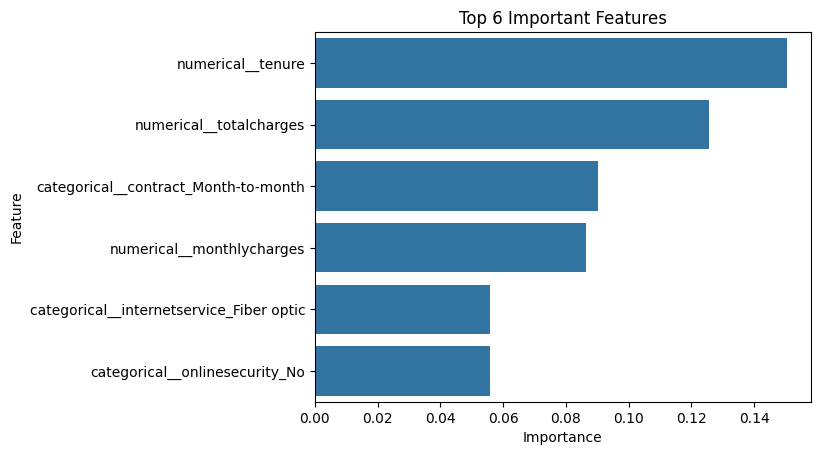

In [48]:
top_6 = feature_importance.head(6)

sns.barplot(
    data=top_6,
    x='Importance',
    y='Feature'
)

plt.title('Top 6 Important Features')
plt.show()